In [66]:
import math
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import periodogram
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_pacf
from matplotlib.offsetbox import AnchoredText

simplefilter("ignore")

# Federal Reserve dataset: https://www.kaggle.com/federalreserve/interest-rates
# reserve = pd.read_csv(
#     "../input/ts-course-data/reserve.csv",
#     parse_dates={'Date': ['Year', 'Month', 'Day']},
#     index_col='Date',
# )

# y = reserve.loc[:, 'Unemployment Rate'].dropna().to_period('M')
# df = pd.DataFrame({
#     'y': y,
#     'y_lag_1': y.shift(1),
#     'y_lag_2': y.shift(2),    
# })

# df.head()

In [93]:
data_dir = Path("../../Time Series/store-sales-time-series-forecasting")
federal_reserve = pd.read_csv(data_dir / "federal_reserve.csv")

federal_reserve.head()

,Year,Month,Day,Federal Funds Target Rate,Federal Funds Upper Target,Federal Funds Lower Target,Effective Federal Funds Rate,Real GDP (Percent Change),Unemployment Rate,Inflation Rate
0,1954,7,1,NaN,NaN,NaN,0.80,4.6,5.8,NaN
1,1954,8,1,NaN,NaN,NaN,1.22,NaN,6.0,NaN
2,1954,9,1,NaN,NaN,NaN,1.06,NaN,6.1,NaN
3,1954,10,1,NaN,NaN,NaN,0.85,8.0,5.7,NaN
4,1954,11,1,NaN,NaN,NaN,0.83,NaN,5.3,NaN


In [94]:
federal_reserve[['Year','Month']].isnull().sum()

Year     0
Month    0
dtype: int64

In [95]:
federal_reserve['Date'] = pd.to_datetime(federal_reserve[["Year", "Month", "Day"]])

federal_reserve['Time'] = (federal_reserve['Year'].astype(str) + "-" + federal_reserve["Month"].astype(str).str.zfill(2))

federal_reserve['Funds Rate'] = federal_reserve['Effective Federal Funds Rate']

federal_reserve = federal_reserve.drop(columns=["Federal Funds Target Rate", "Federal Funds Upper Target", "Federal Funds Lower Target","Year","Month",
                                                "Real GDP (Percent Change)", "Inflation Rate", "Effective Federal Funds Rate"])

federal_reserve.head()

,Day,Unemployment Rate,Date,Time,Funds Rate
0,1,5.8,1954-07-01,1954-07,0.80
1,1,6.0,1954-08-01,1954-08,1.22
2,1,6.1,1954-09-01,1954-09,1.06
3,1,5.7,1954-10-01,1954-10,0.85
4,1,5.3,1954-11-01,1954-11,0.83


In [96]:
federal_reserve.isnull().sum()

Day                    0
Unemployment Rate    152
Date                   0
Time                   0
Funds Rate           152
dtype: int64

In [97]:
federal_reserve['Funds Rate'].fillna(federal_reserve['Funds Rate'].mean(), inplace=True)
federal_reserve.head()

,Day,Unemployment Rate,Date,Time,Funds Rate
0,1,5.8,1954-07-01,1954-07,0.80
1,1,6.0,1954-08-01,1954-08,1.22
2,1,6.1,1954-09-01,1954-09,1.06
3,1,5.7,1954-10-01,1954-10,0.85
4,1,5.3,1954-11-01,1954-11,0.83


In [98]:
print("Maximum Federal Funds Rate: "+ federal_reserve['Funds Rate'].max().astype(str))
print("Minimum Federal Funds Rate: "+ federal_reserve['Funds Rate'].min().astype(str))

Maximum Federal Funds Rate: 19.1
Minimum Federal Funds Rate: 0.07


In [99]:
federal_reserve['lag_1'] = federal_reserve['Funds Rate'].shift(1)
federal_reserve['Lag_2'] = federal_reserve['Funds Rate'].shift(2)
federal_reserve['Lag_3'] = federal_reserve['Funds Rate'].shift(3)

federal_reserve = federal_reserve.drop(columns=["Day", "Date"])
# federal_reserve.to_period()

federal_reserve.head()

,Unemployment Rate,Time,Funds Rate,lag_1,Lag_2,Lag_3
0,5.8,1954-07,0.80,NaN,NaN,NaN
1,6.0,1954-08,1.22,0.80,NaN,NaN
2,6.1,1954-09,1.06,1.22,0.80,NaN
3,5.7,1954-10,0.85,1.06,1.22,0.80
4,5.3,1954-11,0.83,0.85,1.06,1.22


In [100]:
federal_reserve.shape

(904, 6)

In [101]:
# Set Matplotlib defaults
sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(16, 6))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'

def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    x_ = x.shift(lag)

    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()

    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x

    corr = y_.corr(x_)

    if ax is None:
        fig, ax = plt.subplots()
    
    scatter_kws = dict(alpha=0.75, s=3)
    line_kws = dict(color='C3')

    # Use sns.regplot directly and pass ax to it
    sns.regplot(x=x_, y=y_, ax=ax, scatter_kws=scatter_kws, line_kws=line_kws, lowess=True, **kwargs)
    
    # Add correlation as anchored text
    at = AnchoredText(f"{corr:.2f}", prop=dict(size="large"), frameon=True, loc="upper left")
    at.patch.set_boxstyle("square,pad=0.0")
    ax.add_artist(at)
    
    # Set axis labels and title
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)

    return ax

def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2 + 0.5, nrows * 2))  # Ensure it's a tuple


    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k+1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')

    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)

    return fig

In [102]:
funds_rate = federal_reserve.drop(columns=["lag_1","Lag_2","Lag_3"])
funds_rate.head()

,Unemployment Rate,Time,Funds Rate
0,5.8,1954-07,0.80
1,6.0,1954-08,1.22
2,6.1,1954-09,1.06
3,5.7,1954-10,0.85
4,5.3,1954-11,0.83


In [103]:
funds_rate['Funds_Rate'] = funds_rate['Funds Rate']
funds_rate['Unemployment_Rate'] = funds_rate['Unemployment Rate']
funds_rate = funds_rate.drop(columns=["Funds Rate","Unemployment Rate"])
funds_rate.head()

,Time,Funds_Rate,Unemployment_Rate
0,1954-07,0.80,5.8
1,1954-08,1.22,6.0
2,1954-09,1.06,6.1
3,1954-10,0.85,5.7
4,1954-11,0.83,5.3


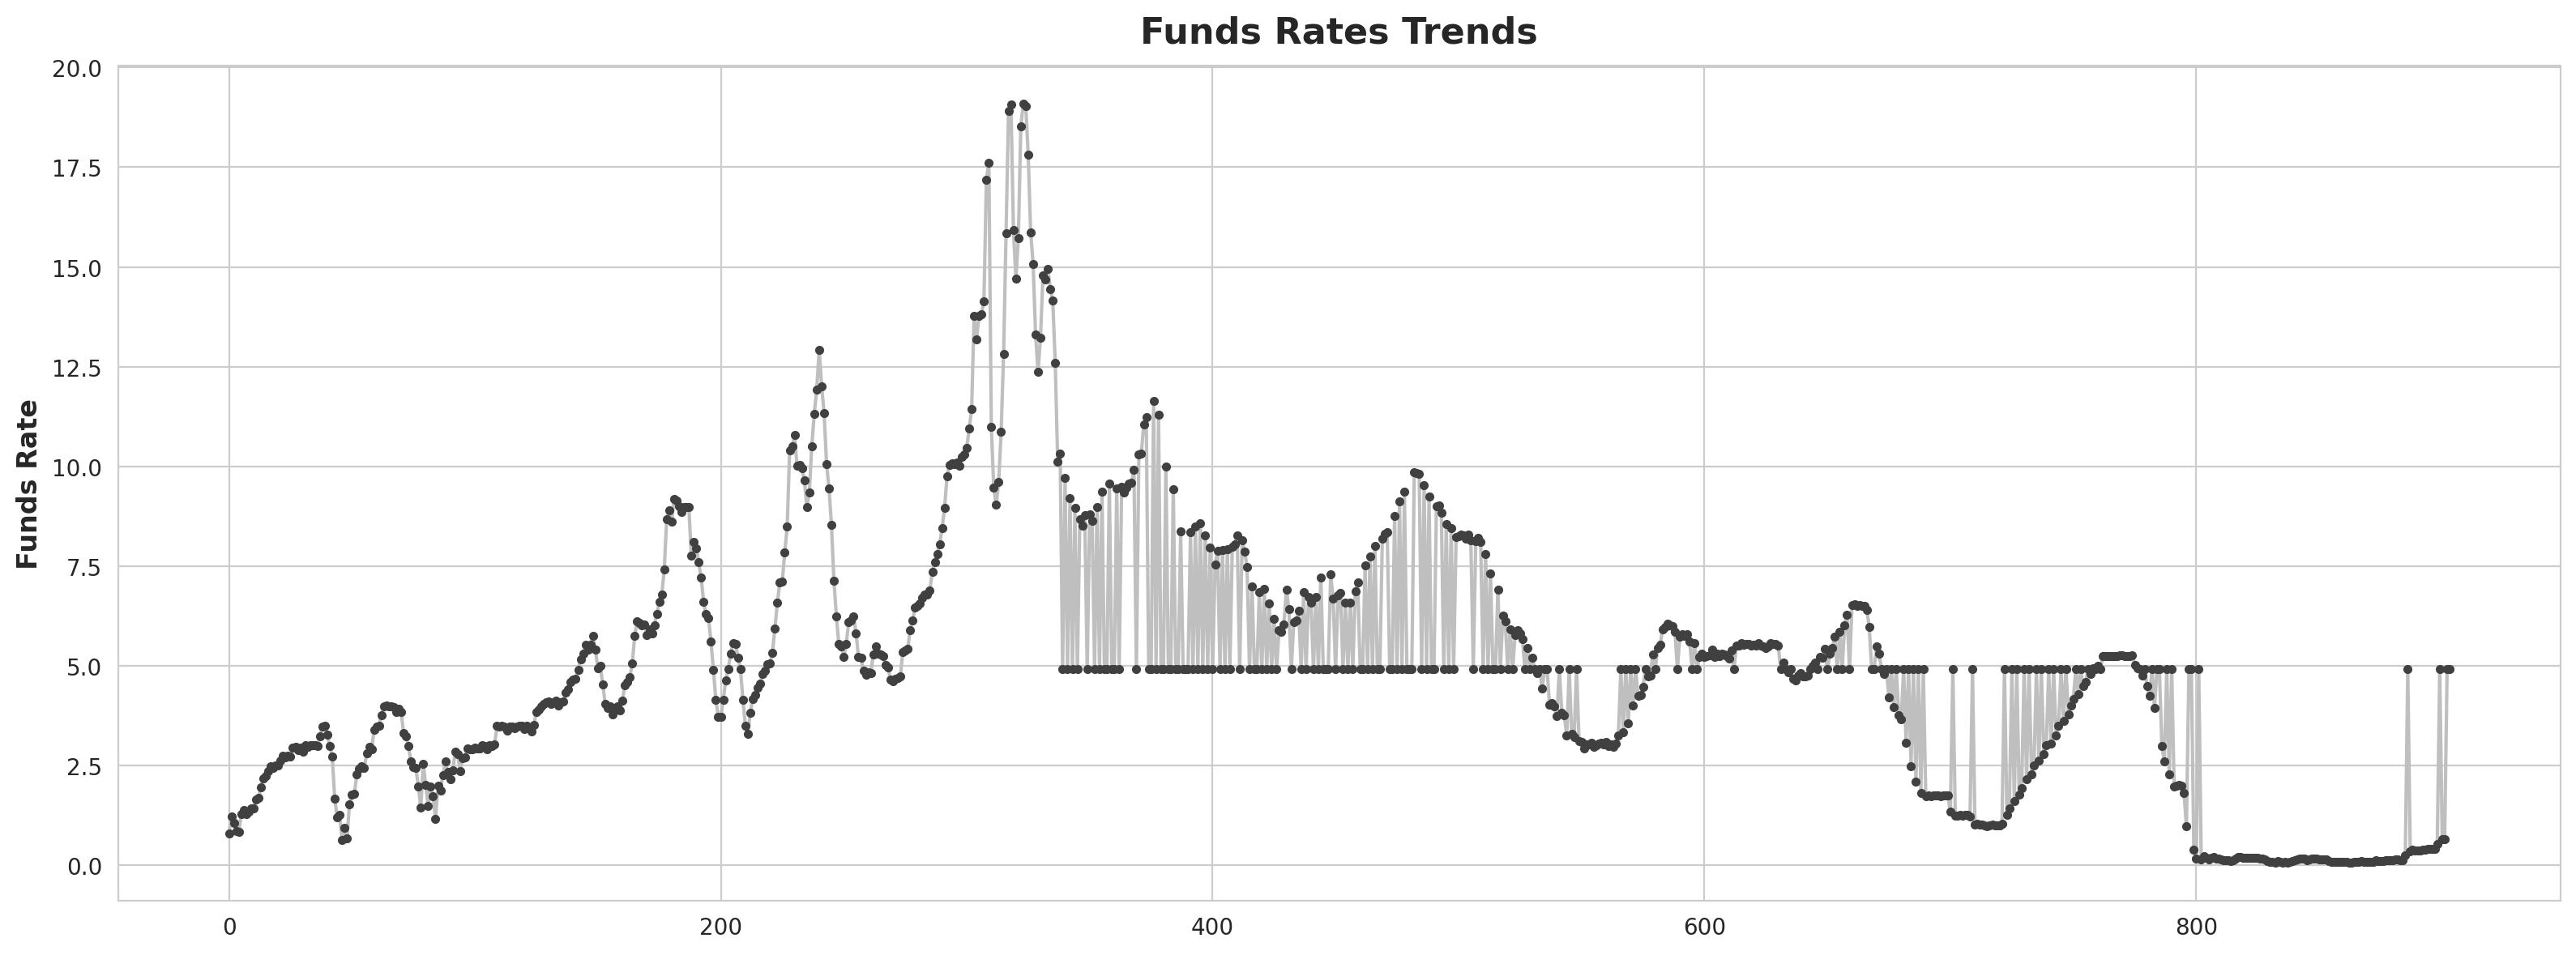

In [104]:
ax = funds_rate.Funds_Rate.plot(title='Funds Rates Trends', **plot_params)
_ = ax.set(ylabel="Funds Rate")

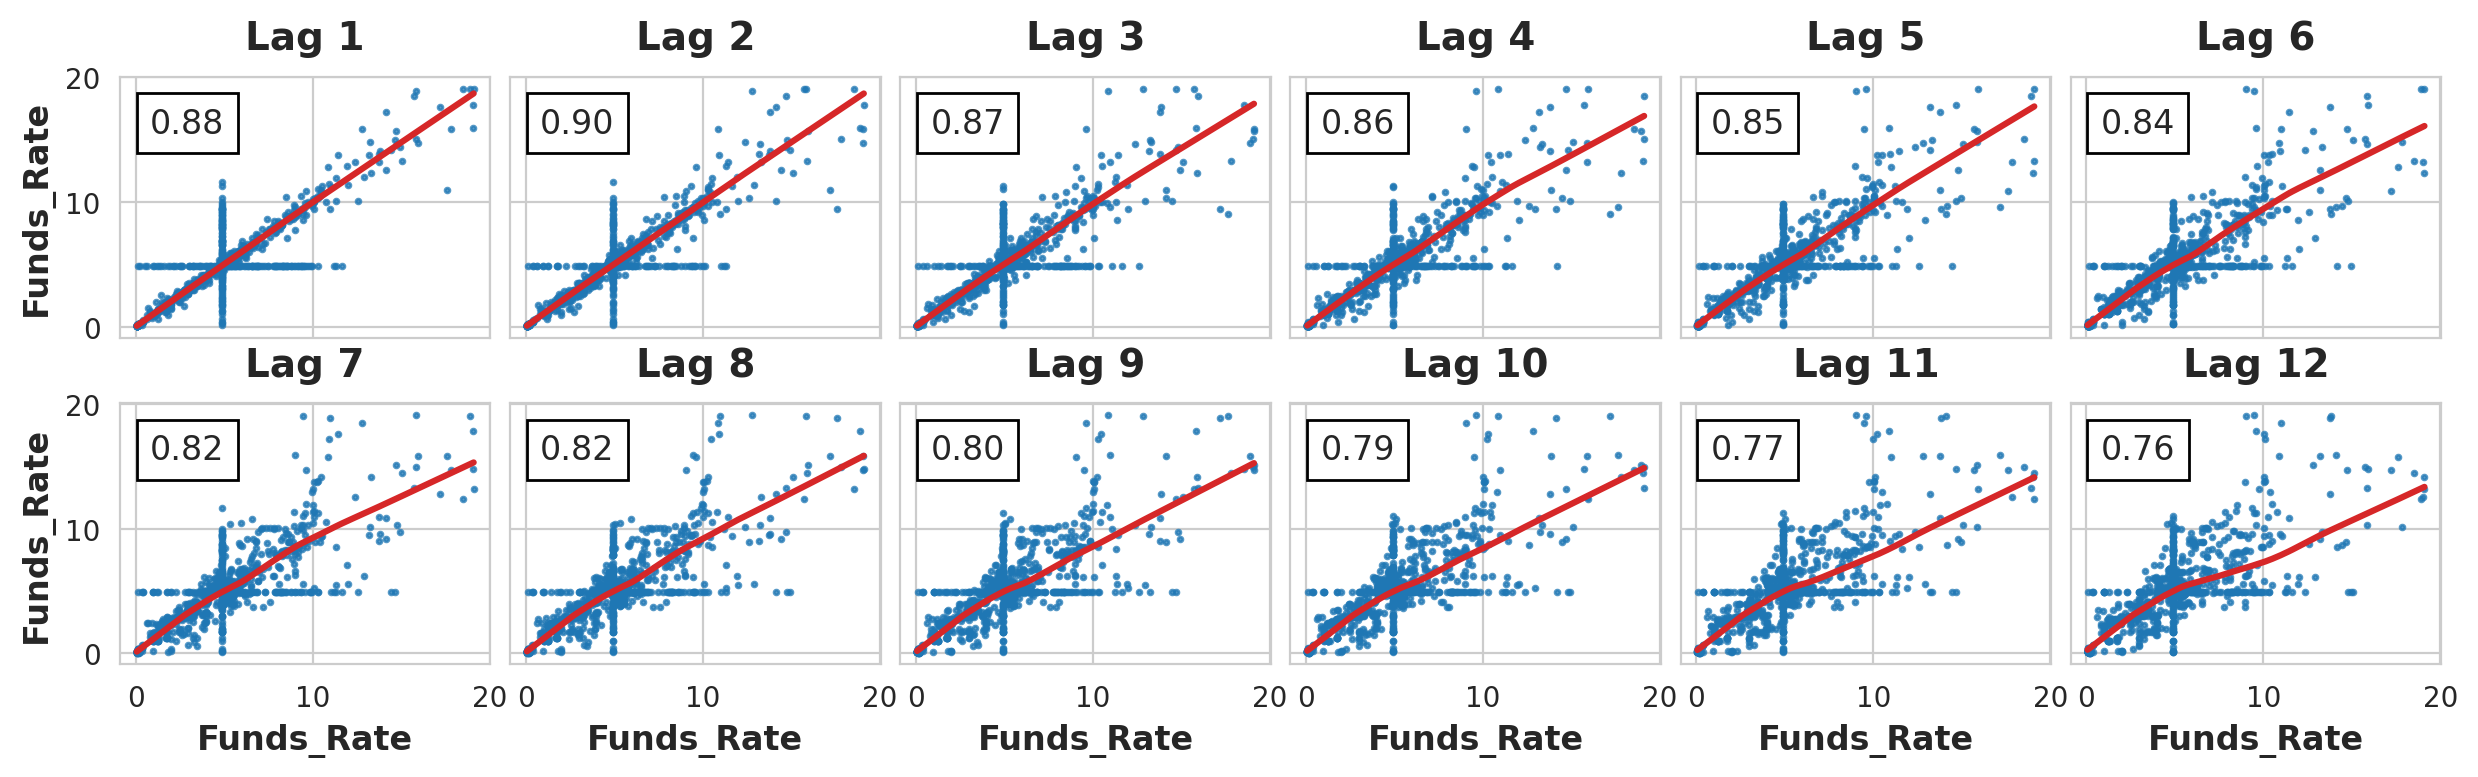

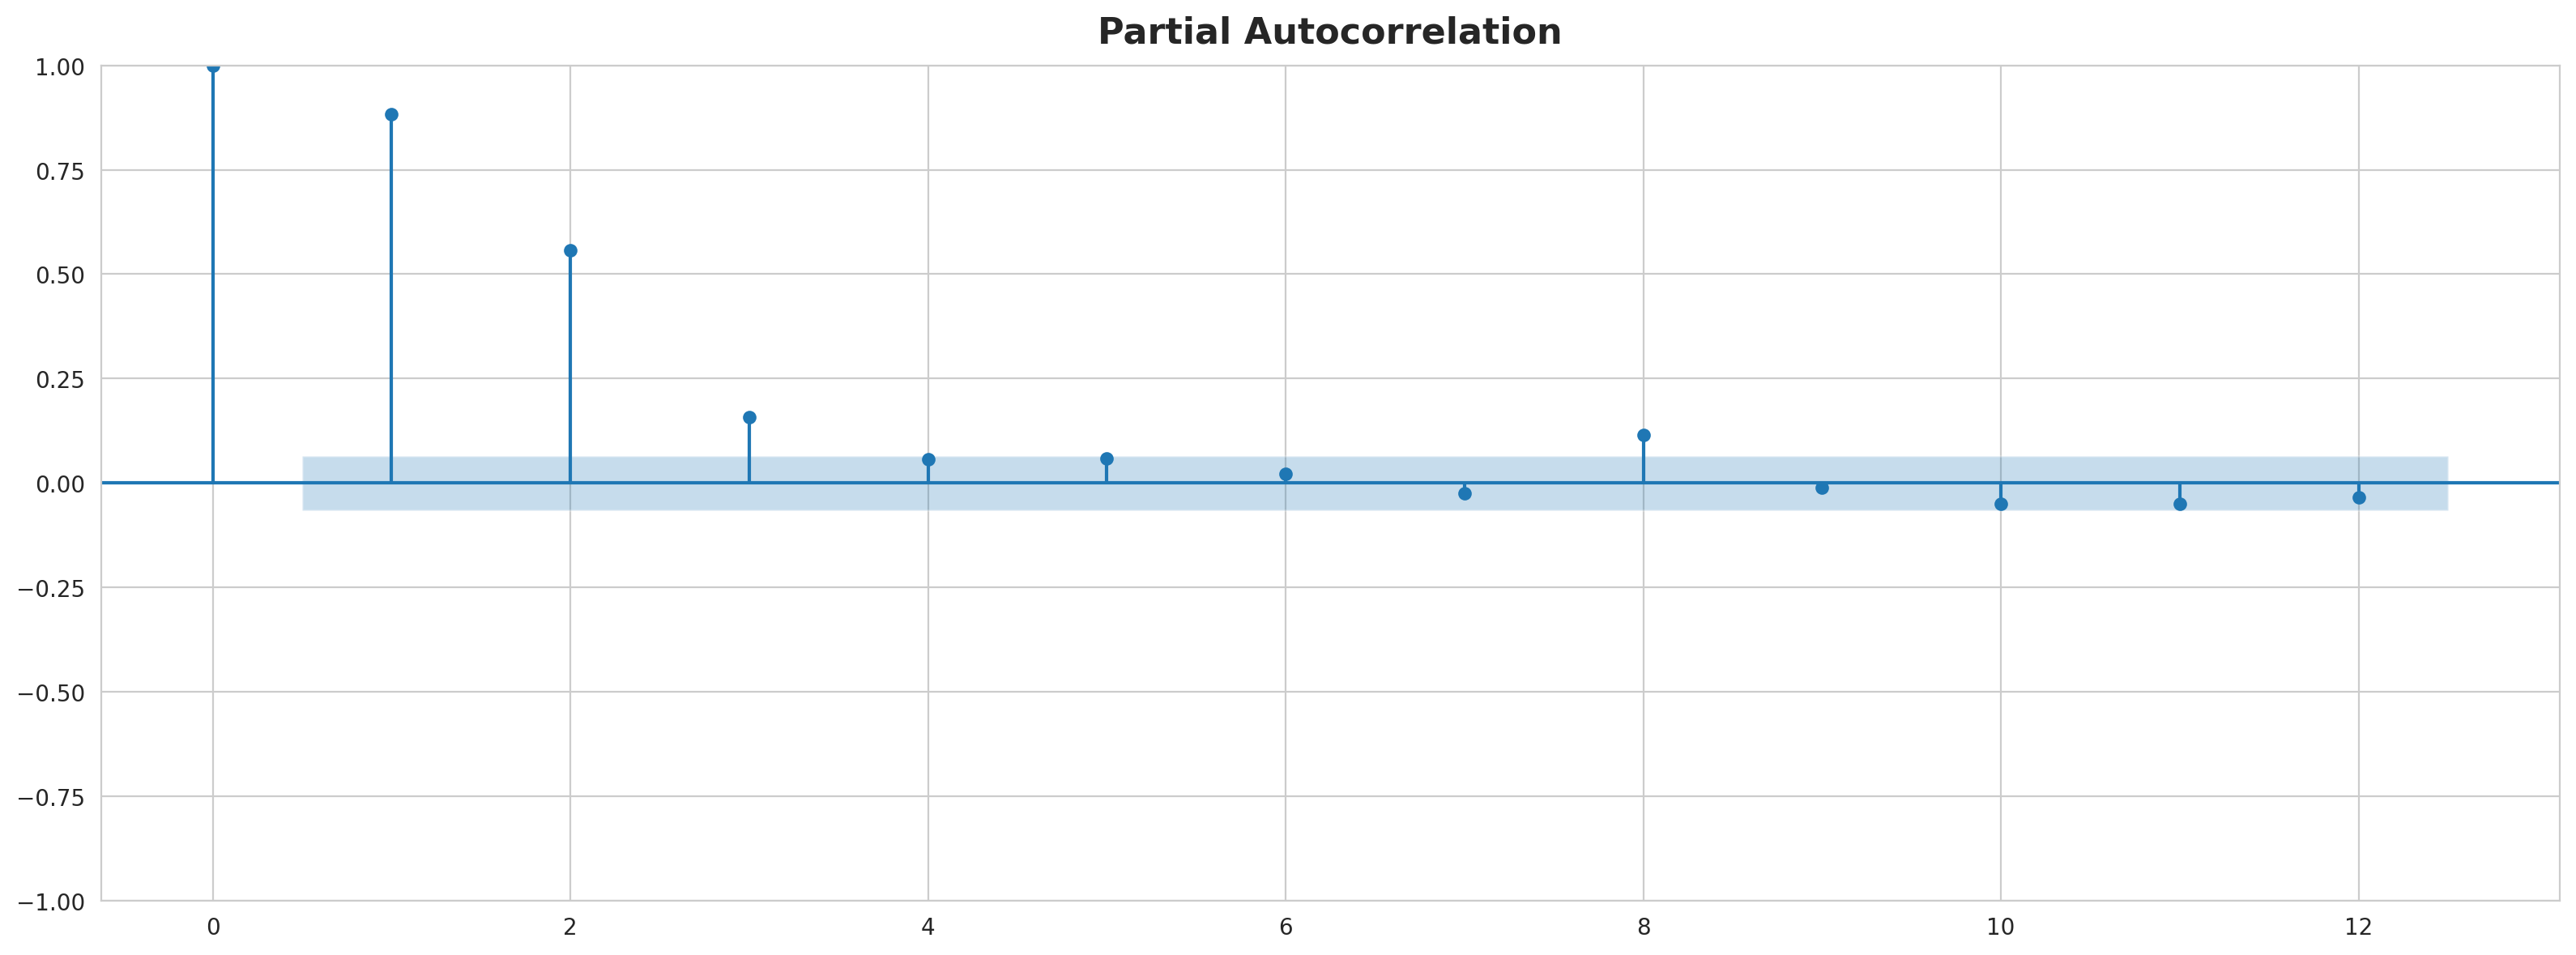

In [81]:
_ = plot_lags(funds_rate.Funds_Rate, lags=12, nrows=2)
_ = plot_pacf(funds_rate.Funds_Rate, lags=12)

In [105]:
def make_lags(ts, lags):
    return pd.concat(
        {
            f"y_lag_{i}": ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1
    )

X = make_lags(funds_rate.Funds_Rate, lags=4)
X = X.fillna(0.0)

In [106]:
y = funds_rate.Funds_Rate.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)
y_predictions = pd.Series(model.predict(X_train), index=y_train.index)
y_forecast = pd.Series(model.predict(X_test), index=y_test.index)

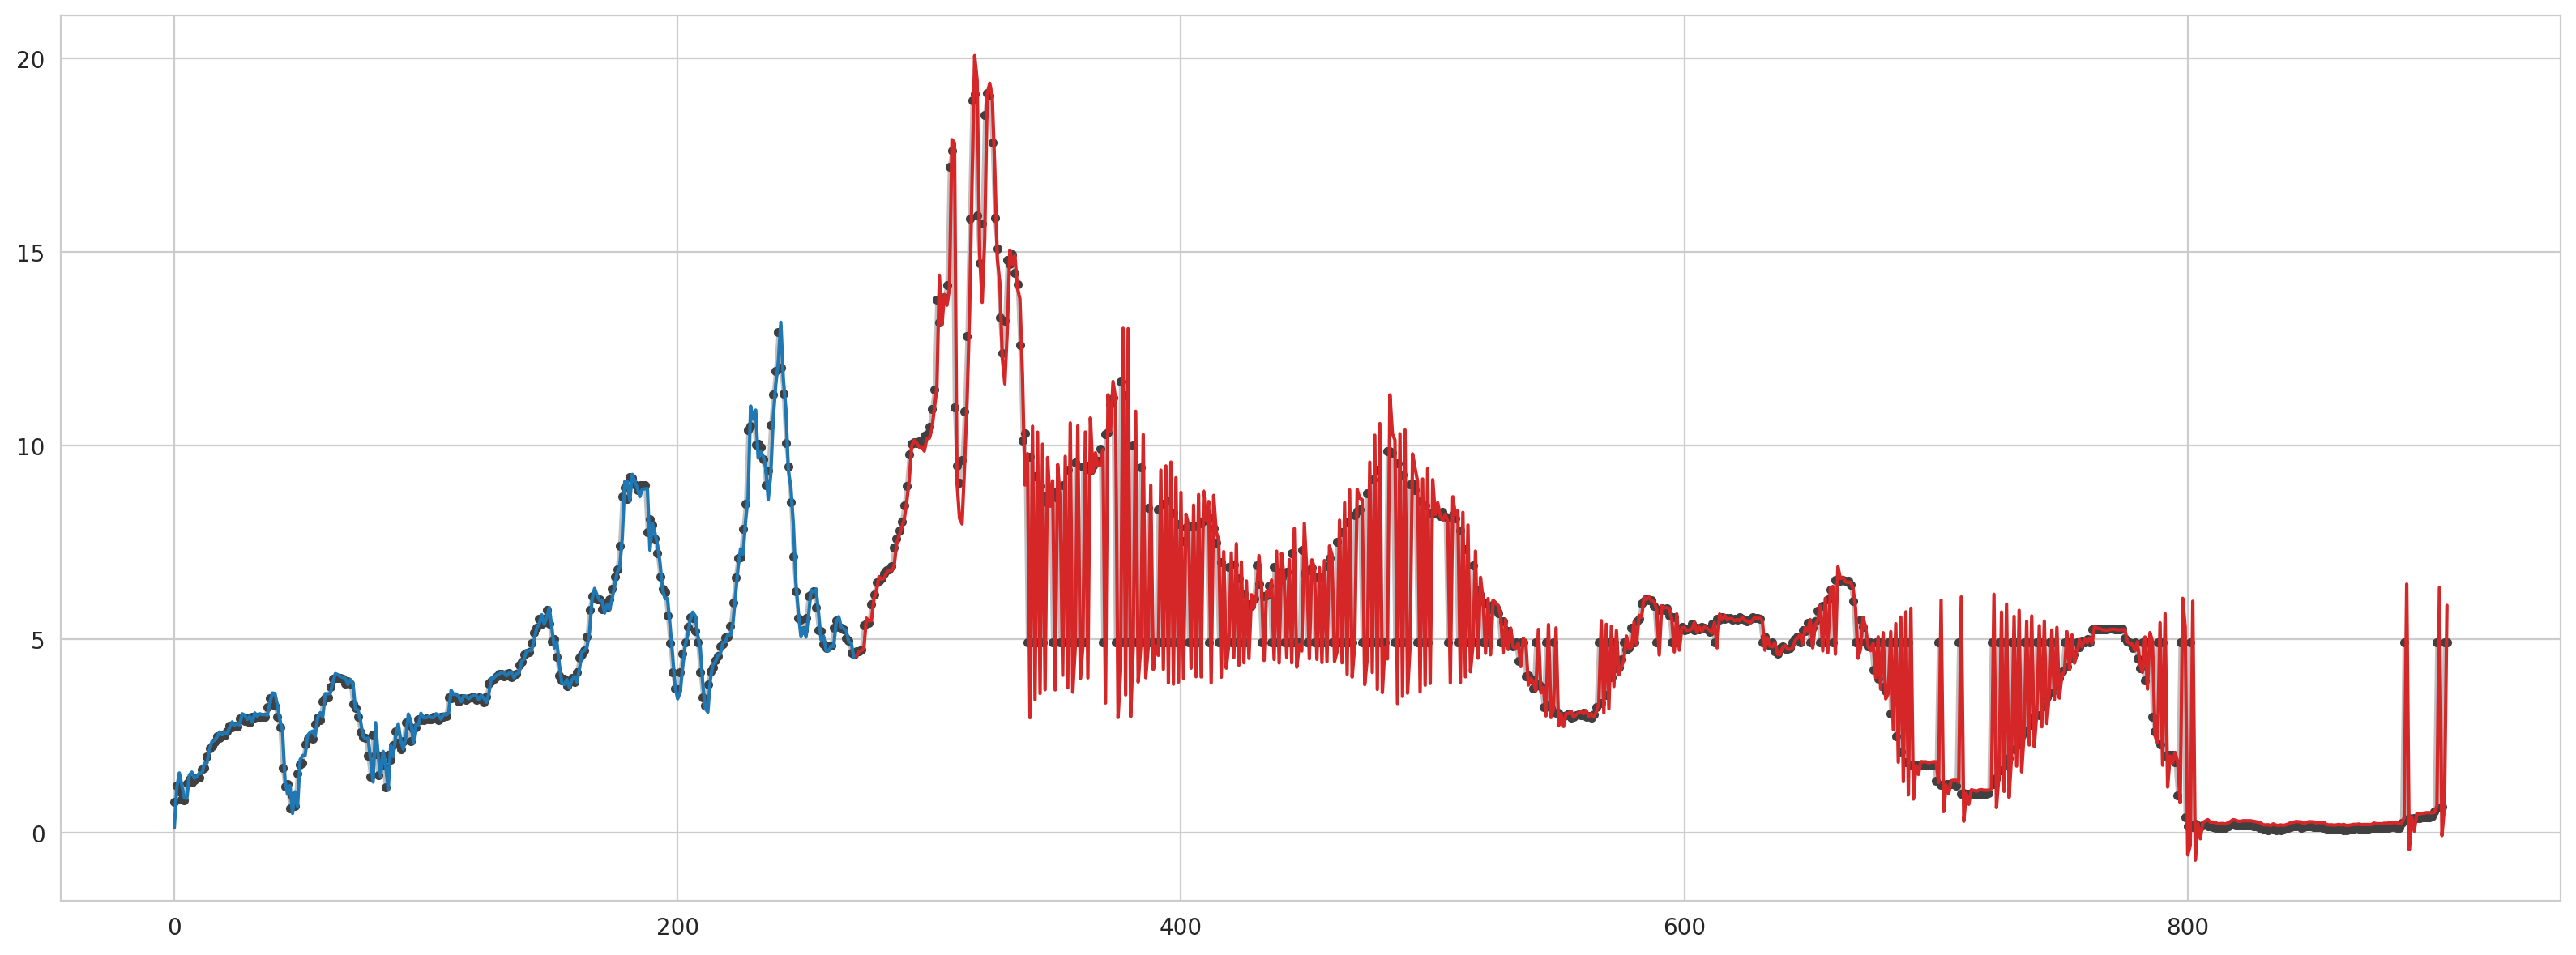

In [107]:
ax = y_train.plot(**plot_params)
ax = y_test.plot(**plot_params)
ax = y_predictions.plot(ax=ax)
_ = y_forecast.plot(ax=ax, color='C3')

---

Looking just at the forecast values, we can see how our model needs a time step to react to sudden changes in the target series. This is a common limitation of models using only lags of the target series as features.

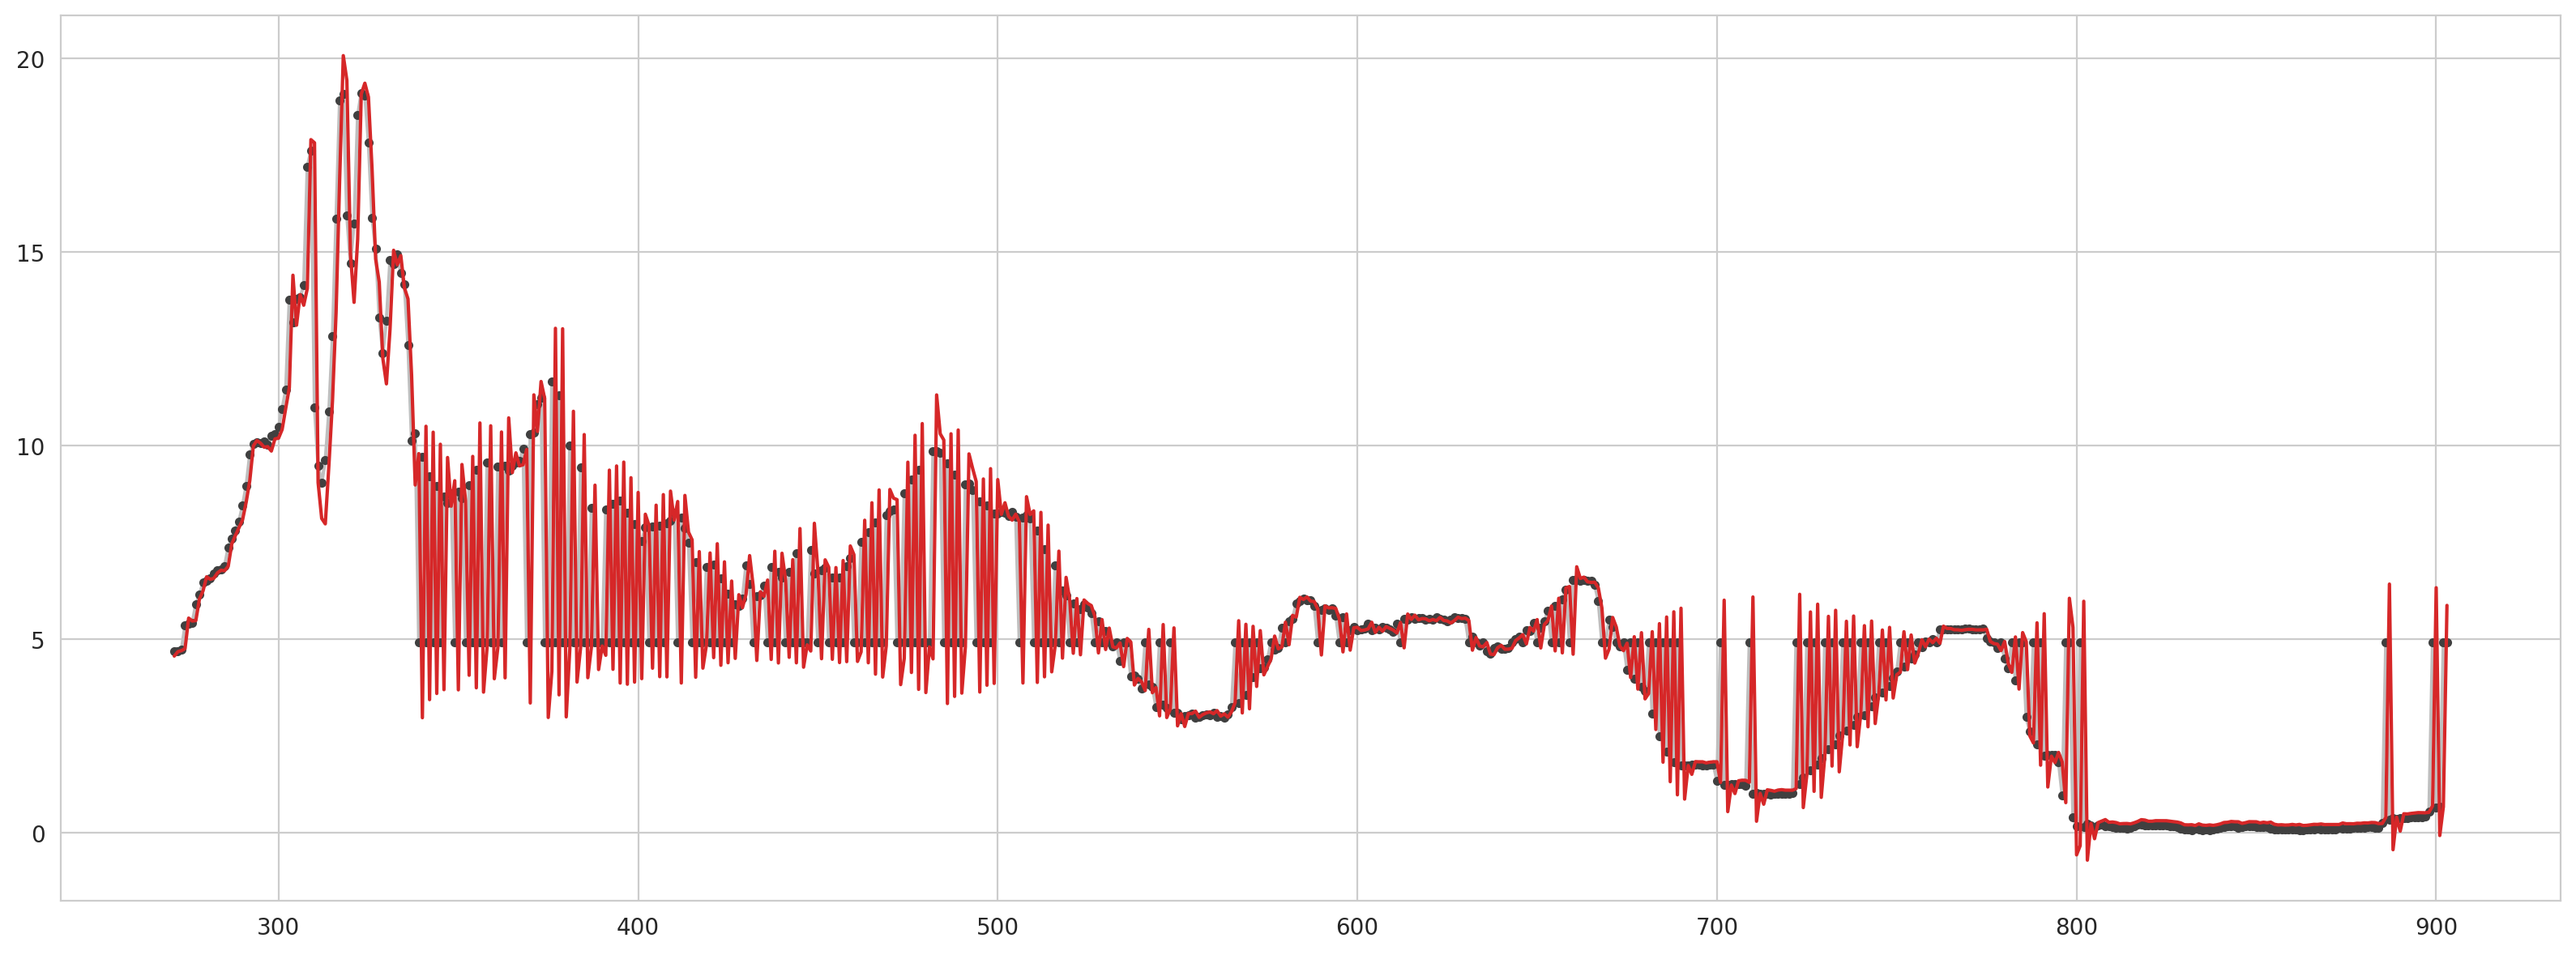

In [108]:
ax = y_test.plot(**plot_params)
_ = y_forecast.plot(ax=ax, color='C3')

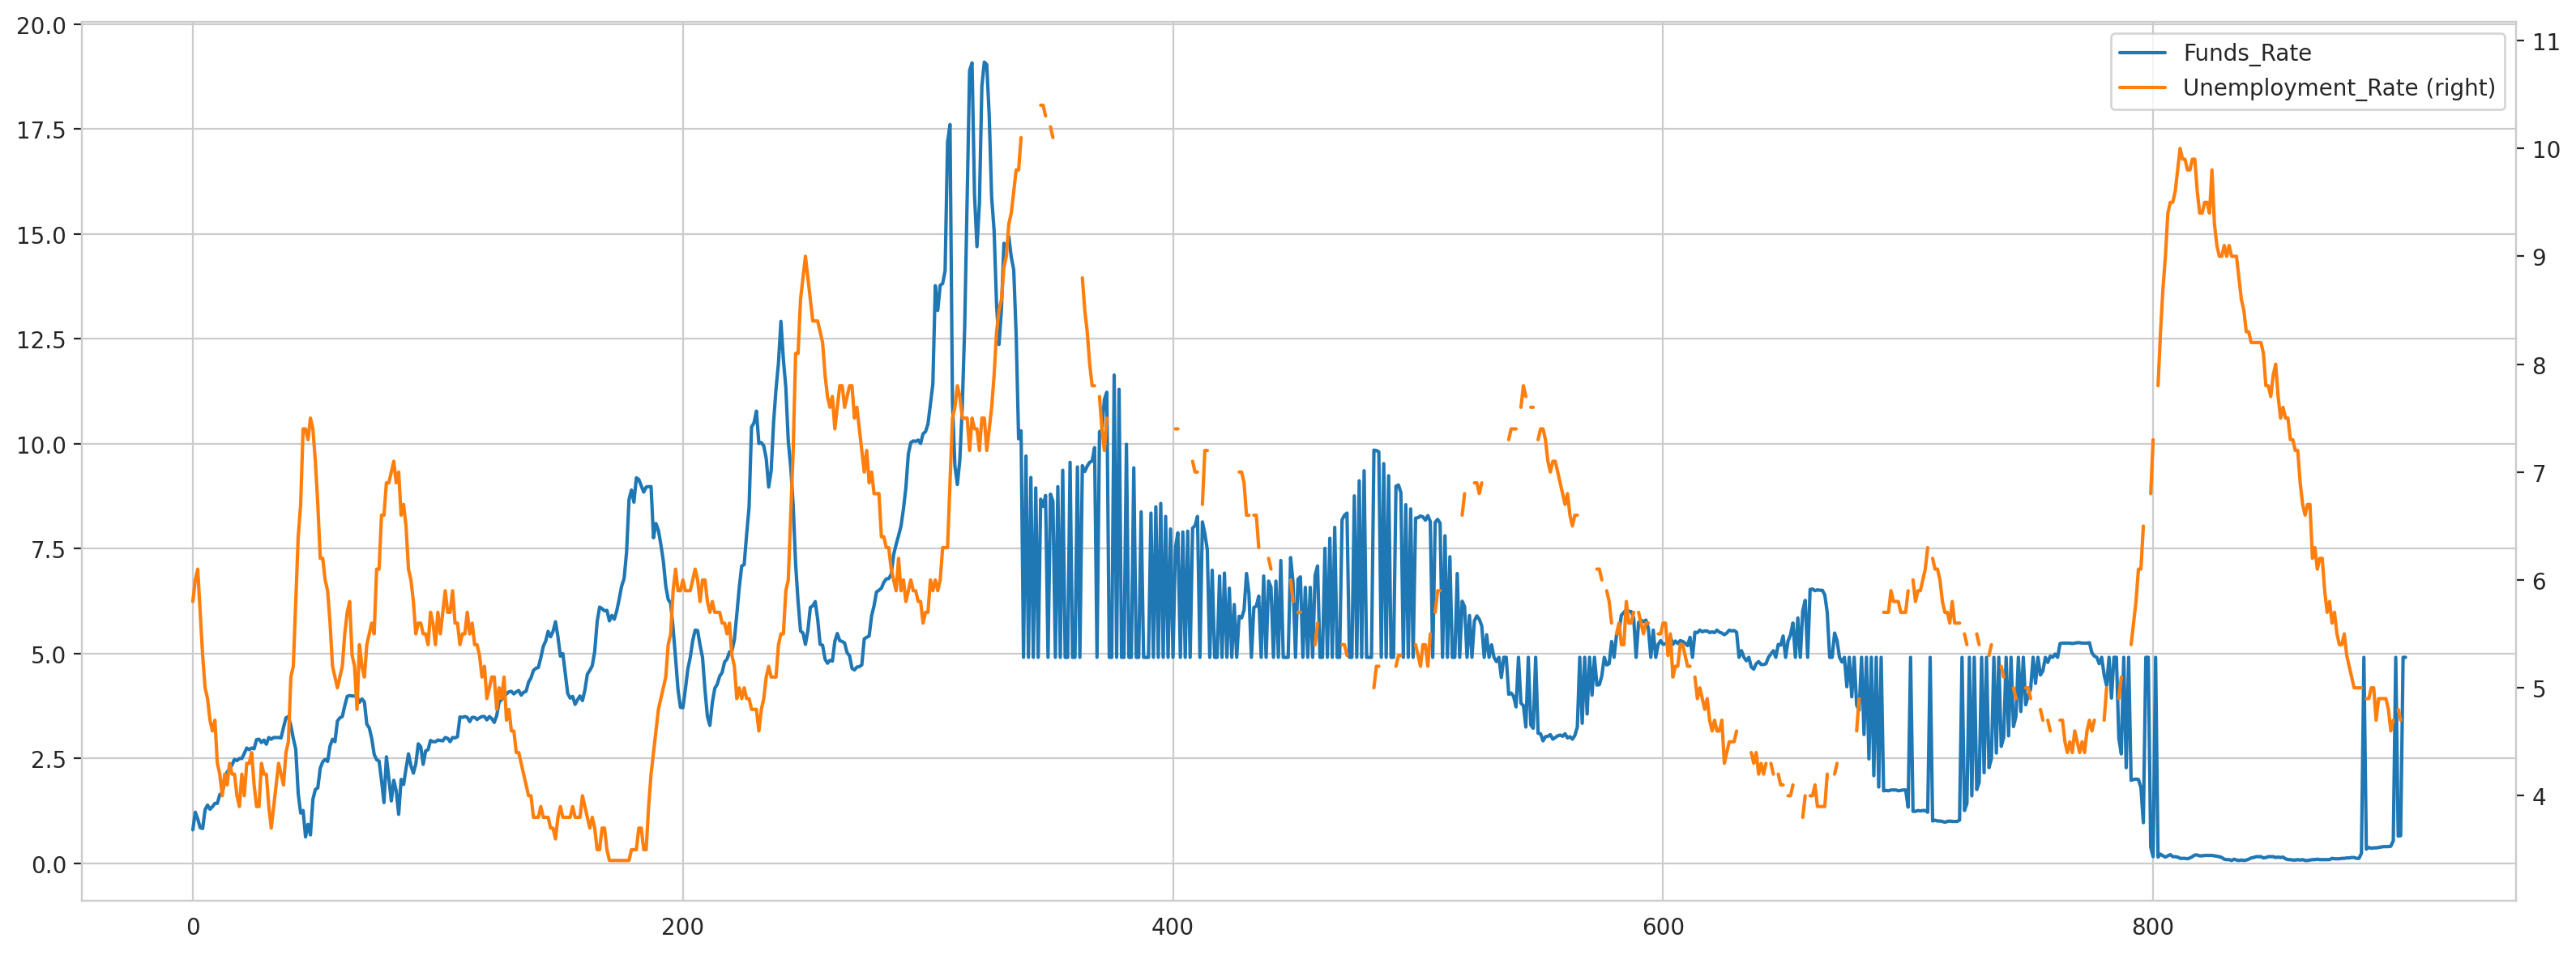

In [109]:
ax = funds_rate.plot(
    y=["Funds_Rate", "Unemployment_Rate"],
    secondary_y="Unemployment_Rate",
)